## Linear Regression from Scratch

Linear Regression is a supervised machine learning algorithm used to model the relationship 
between a dependent variable (y) and one or more independent variables (X).

In this exp, we implement Linear Regression  using:
1. Least Squares Method (Closed Form Solution)
2. Gradient Descent Method (Iterative Optimization)



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Given Dataset
X = np.array([1, 3, 4, 7, 8])
y = np.array([1,2.5, 4.5, 6, 8.5])

# Reshaping data for doing matrix operations
X = X.reshape(-1,1)

Linear Regression Model

The hypothesis function is:

\[
Y = wX + b
\]

Where:
- \( w \) = weight
- \( b \) = bias
- \( X \) = input feature
- \( Y \) = predicted output


 Least Squares Method (M1)

The optimal weights are obtained by minimizing the cost function:

$$
J(\mathbf{w}) = \sum_{i=1}^{n} \left( y_i - \mathbf{X}_i \mathbf{w} \right)^2
$$

 Closed-form Solution

The optimal weight vector is given by:

$$
\mathbf{w} = \left( \mathbf{X}^T \mathbf{X} \right)^{-1} \mathbf{X}^T \mathbf{y}
$$


In [2]:
# Adding Bias Column
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Least Square formula
Xt = X_b.T
XtX = Xt @ X_b
XtX_inverse = np.linalg.inv(XtX)
Xty = Xt @ y

thetha = XtX_inverse @ Xty

# printing weights and bias
bias = thetha[0]
weight = thetha[1]

print("LSM Result:")
print("Weight (w:)", weight)
print("bias (b):", bias)

# making predictions on the given data
y_pred_ls = X_b @ thetha

LSM Result:
Weight (w:) 0.9939759036144581
bias (b): -0.07228915662650448


All step meaning:
1. reshape = here we make "X" as a column so we can do matrix operations.
2. np.ones = adding "1" for bias
3. X_b = [1, x] format
4. thetha = a term for getting the values of formula
5. thetha[0] = bias
6. thetha[1] = weight

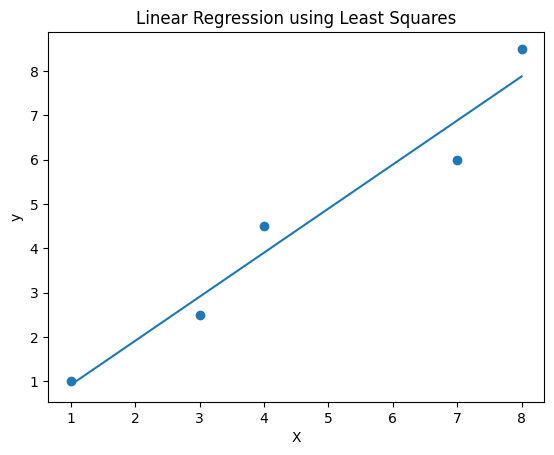

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, y_pred_ls)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression using Least Squares")
plt.show()

### Intuition

- The loss function tells us how wrong our predictions are.
- Gradient Descent moves the parameters in the direction of minimum error.
- The learning rate $\alpha$ controls how big each step is.
- Small $\alpha$ → slow learning  
- Large $\alpha$ → unstable learning


## Gradient Descent Method

Gradient Descent is an iterative optimization algorithm used to minimize the loss function 
by updating the parameters step by step.

### Loss Function (Mean Squared Error)

$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$

Where the prediction is given by:

$$
\hat{y}_i = w x_i + b
$$

### Gradient Update Rules

The parameters are updated using the following equations:

$$
w = w - \alpha \frac{\partial J}{\partial w}
$$

$$
b = b - \alpha \frac{\partial J}{\partial b}
$$

### Partial Derivatives

The gradients of the loss function are:

$$
\frac{\partial J}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} ( \hat{y}_i - y_i ) x_i
$$

$$
\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} ( \hat{y}_i - y_i )
$$


In [6]:
# intializing parameters
w=0.0
b=0.0
lr=0.01
epochs = 100
losses = []

n = len(X)

for epoch in range(epochs):
    y_pred = w * X.flatten() + b
    error = y_pred - y

# Loss
loss = np.mean(error ** 2)
losses.append(loss)

# Gradients
dw = (2/n) * np.sum(error * X.flatten())
db = (2/n) * np.sum(error)

# Update rule
w -= lr * dw
b -= lr * db

print("Gradient Descent Method:")
print("weight (w)", w)
print("Bias (b)", b)

y_pred_gd = w * X.flatten() + b
print("Total losses stored:", len(losses))
print("Epochs:", epochs)

Gradient Descent Method:
weight (w) 0.546
Bias (b) 0.09
Total losses stored: 1
Epochs: 100


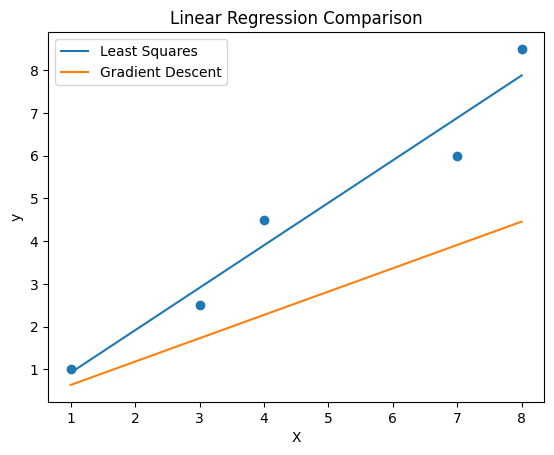

In [7]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, y_pred_ls, label="Least Squares")
plt.plot(X, y_pred_gd, label="Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression Comparison")
plt.show()


In [8]:
print(len(losses))


1


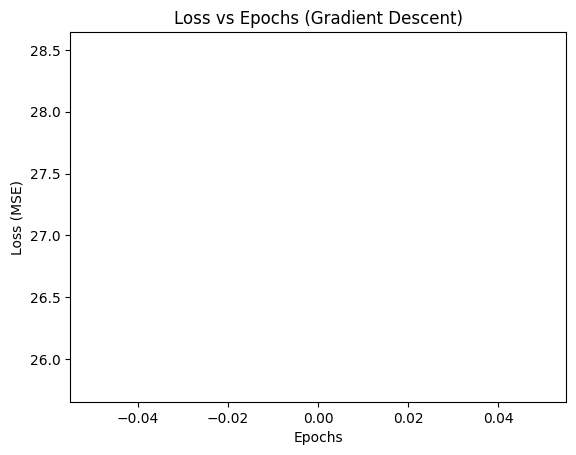

In [9]:
plt.figure()
plt.plot(range(len(losses)), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs (Gradient Descent)")
plt.show()


## Comparison

| Method | Type | Speed | Accuracy |
|------|------|------|---------|
| Least Squares | Closed-form | Fast | Exact |
| Gradient Descent | Iterative | Slower | Approximate |

## Conclusion

- Least Squares works well for small datasets.
- Gradient Descent is preferred for large-scale data.
